In [1]:
import import_helper
import_helper.add_models()

import model.conditions as ic
import model.nondim_kondo_model as nondim_kondo
import model.mesh_generation as meshgen
import model.intensity_analysis as analyse

import os
from fenics import *
from mshr import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'magma'
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"

### Reaction-diffusion model (from Kondo group)

Model is adapted in Tewary et al (2017), using mixed boundary conditions (Dirichlet for A and Neumann for I).

\begin{align}
    \frac{\partial A}{\partial t} &= D_A \nabla^2 A - d_A A + F_A(A, I) \\
    \frac{\partial I}{\partial t} &= D_I \nabla^2 I - d_I I + F_I(A, I)
\end{align}

where the three terms for both equations represent the diffusion, degradation and production functions. We take the production functions to be 
\begin{align}
    F_A(A, I) &= \max\{0, \min\{A^{\max}, a_A A + b_A I + c_A\}\} \\
    F_I(A, I) &= \max\{0, \min\{I^{\max}, a_I A + b_I I + c_I\}\}
\end{align}

and mixed boundary conditions with Dirichlet for activator and Neumann for inhibitor (justification):
\begin{align}
    A = A^{\max}, \mathbf{n} \cdot \nabla I = 0 \text{ for all } \mathbf{x} \in \partial \Omega
\end{align}

#### Non-dimensionalisation
We non-dimensionalised the system for a more systematic parameter search. The model for the dimensionless concentrations $\tilde{A}, \tilde{I}$, in terms of dimensionless space, $\tilde{x}$ and time $\tau$
\begin{align}
    \frac{\partial \tilde{A}}{\partial \tau} &= \frac{\partial^2 \tilde{A}}{\partial \tilde{x}^2} + \gamma \left( \tilde{F}_{\tilde{A}}(\tilde{A}, \tilde{I}) - \tilde{A} \right), \\
    \frac{\partial \tilde{I}}{\partial \tau} &= \delta \frac{\partial^2 \tilde{I}}{\partial \tilde{x}^2} + \gamma \left(\tilde{F}_{\tilde{I}}(\tilde{A}, \tilde{I}) - \kappa \tilde{I} \right),
\end{align}
where
\begin{align}
    \tilde{F}_{\tilde{A}}(\tilde{A}, \tilde{I}) &= \frac{1}{d_A} \max \left \{0, \min \left \{\frac{A^{\max}}{A^{\text{bound}}}, a_A \tilde{A} + b_A \tilde{I} + \frac{c_A}{A^{\text{bound}}} \right \} \right \}, \\
    \tilde{F}_{\tilde{I}}(\tilde{A}, \tilde{I}) &= \frac{1}{d_A} \max \left \{0, \min \left \{\frac{I^{\max}}{A^{\text{bound}}}, a_I \tilde{A} + b_I \tilde{I} + \frac{c_I}{A^{\text{bound}}} \right \} \right \}. \\
\end{align}
The boundary conditions are now
\begin{align}
    \tilde{A} = 1, \mathbf{n} \cdot \nabla \tilde{I} = 0 \text{ for all } \mathbf{\tilde{x}} \in \partial \Omega.
\end{align}

100%|██████████| 9/9 [00:00<00:00, 412.40it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/home/loo/posterior_neuruloid_patterning/two_step_model/notebooks/annulus/gamma5.png'

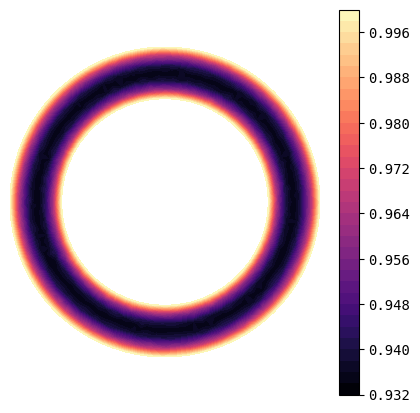

In [ ]:
# solve kondo model with fixed set of parameters and varying gamma (5-150)
# and save into csv file and save png for each

# define fixed params
Amax_nd = 2 #0.06 / 0.03 # max for production term
Imax_nd = 5 #0.17 / 0.03 # max for production term
delta = 20
aA = 8/3 #0.08 / 0.03
bA = -8/3 #-0.08 / 0.03
cA_nd = 1/18
dA = 1 #0.03 * 100
aI = 10/3 #0.1 / 0.03
bI = 0
cI_nd = -1/6
dI = 2 
kappa = 2
Aeq_nd, Ieq_nd = nondim_kondo.fixed_points(**{"aA":aA, "bA":bA, "cA":cA_nd, "dA":dA,
                                              "aI":aI, "bI":bI, "cI":cI_nd, "dI":dI})
# define initial conditions
u0 = ic.InitialConditionsRandom(noise=0.001, Ac=Aeq_nd, Ic=Ieq_nd)
Tend = 1

# gamma to try
gamma_array = np.arange(5, 101, 1)
# define mesh
Rout, Rin = 1, 1/1.5
mesh = meshgen.annulus(Rout, Rin, res=25)
distances = np.linspace(0, 1, 11) # define distance for contour

# insert csv path to save
save_file = "simulation_intensity_annulus.csv"
dataframe = pd.DataFrame()

for i in range(len(gamma_array)):
    gamma = gamma_array[i]
    non_dim_param = {"delta":delta, "gamma":gamma, "kappa":kappa,
                    "Amax_nd":Amax_nd, "Imax_nd":Imax_nd, 
                    "aA":aA, "bA":bA, "cA_nd":cA_nd, "dA":dA,
                    "aI":aI, "bI":bI, "cI_nd":cI_nd}
        
    rd_steady_state = nondim_kondo.dimensionless_kondo(mesh, 
                                                       u0,
                                                       T=Tend, 
                                                       dt=0.1,
                                                       param_set=non_dim_param,
                                                       boundary_conditions="Mixed")
    A, I  = split(rd_steady_state)

    intensity = analyse.intensities_from_contours(distances,
                                                  vertices,
                                                  A,
                                                  mesh,
                                                  plot=False)
    # intensity = analyse.intensity_from_annulus(distances,
    #                                            A,
    #                                            mesh,
    #                                            Rout,
    #                                            Rin)
    dataframe[f"gamma{gamma}"] = intensity # save contour intensities

    # save png plots 
    fig, ax = plt.subplots(figsize=(5,5))
    im = plot(A)
    ax.axis("off")
    fig.colorbar(im)
    fig.savefig(f"annulus/gamma{gamma}.png", transparent=True)
    plt.close(fig)

dataframe.to_csv(save_file)

In [100]:
# insert parameters for dimensionless model
Amax_nd = 2 #0.06 / 0.03 # max for production term
Imax_nd = 5 #0.17 / 0.03 # max for production term

delta = 20
aA = 8/3 #0.08 / 0.03
bA = -8/3 #-0.08 / 0.03
cA_nd = 1/18
dA = 1 #0.03 * 100

aI = 10/3 #0.1 / 0.03
bI = 0
cI_nd = -1/6
dI = 2 
kappa = 2

const_prop = 0.8593 # 2.5
intercept = 5.765
gamma = const_prop * (8.0)**2 + intercept #31.85 #65 #160 #28.9  #84 #235.6 #150.8 #28.9 
print(gamma)

## square
Aeq_nd, Ieq_nd = nondim_kondo.fixed_points(**{"aA":aA, "bA":bA, "cA":cA_nd, "dA":dA,
                                              "aI":aI, "bI":bI, "cI":cI_nd, "dI":dI})
print(Aeq_nd, Ieq_nd)
TI = nondim_kondo.check_Turing_instability(**{"delta":delta, "aA":aA, "bA":bA, "cA":cA_nd, "dA":dA,
                                              "aI":aI, "bI":bI, "cI":cI_nd, "dI":dI})
print(TI)
non_dim_param = {"delta":delta, "gamma":gamma, "kappa":kappa,
                 "Amax_nd":Amax_nd, "Imax_nd":Imax_nd, 
                 "aA":aA, "bA":bA, "cA_nd":cA_nd, "dA":dA,
                 "aI":aI, "bI":bI, "cI_nd":cI_nd}

60.7602
0.09999999999999999 0.08333333333333331
(True, True)


In [101]:
u0 = ic.InitialConditionsRandom(noise=0.001, Ac=Aeq_nd, Ic=Ieq_nd)

# # circle
# mesh = meshgen.circle(R=1, res=30)
# min_dist = 0.5

# square
# square_length = np.sqrt(np.pi)
# min_dist = square_length / 2
# mesh, vertices = meshgen.square(length=square_length, res=30, return_vertices=True)

# triangle_length = np.sqrt(4*np.pi/np.sqrt(3))
# min_dist = (1/np.sqrt(3)) * triangle_length / 2
# mesh, vertices = meshgen.equilateral_triangle(triangle_length, 
#                                               res=30, 
#                                               return_vertices=True)

# star_length = np.sqrt(np.pi)/2
# min_dist = (star_length/2)*np.sqrt(2)
# mesh, vertices = meshgen.four_pointed_star(length=star_length,
#                                            res=30,
#                                            return_vertices=True)

# wavy stars
wavy_star_length = 0.85 # to obtain area=pi
min_dist = wavy_star_length
mesh, vertices = meshgen.wavy_star(octagon_length=wavy_star_length, return_vertices=True)


# print(list(vertices))

In [102]:
print(mesh.hmin())
print(mesh.hmax())

0.054804778181519284
0.1086411559429627


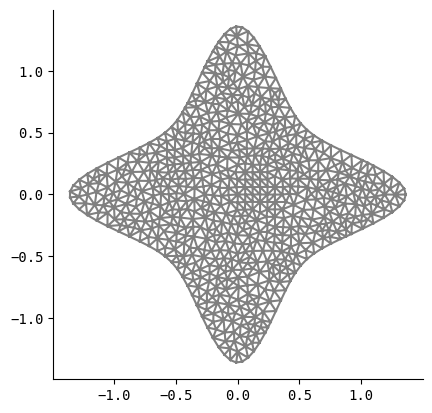

In [103]:
plot(mesh)

In [104]:
Tend = 1
rd_steady_state = nondim_kondo.dimensionless_kondo(mesh, 
                                                   u0,
                                                   T=Tend, 
                                                   dt=0.1,
                                                   param_set=non_dim_param,
                                                   boundary_conditions="Mixed")
A, I  = split(rd_steady_state)

100%|██████████| 10/10 [00:02<00:00,  3.62it/s]


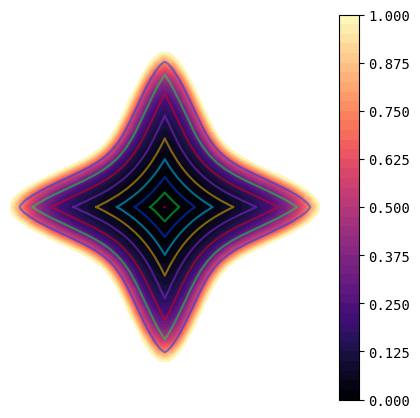

In [106]:
distances = np.linspace(0, min_dist, 11)

fig, ax = plt.subplots(figsize=(5,5))
im = plot(A)
ax.axis("off")
fig.colorbar(im)
intensities_R800 = analyse.intensities_from_contours(distances,
                                                vertices,
                                                A,
                                                mesh,
                                                plot=True,
                                                axes=ax)
# fig.savefig("rd_model_triangle_R350.png", transparent=True)

In [107]:
# save contour intensities
x = np.linspace(0, 1, len(intensities_R800))
df = pd.DataFrame({"radii":x, "intensities":intensities_R800})
df.to_csv("activator_contour_intensity/wavystar_R800.csv")

In [60]:
# read file for contour intensities and plot
FOLDER = "../../image_analysis/contour_intensities" # folder containing intensity values from image analysis
file_name = "norm_tbxt_ctrl_triangle_48hr_800um.csv"
tbxt_df = pd.read_csv(os.path.join(FOLDER, file_name))
column_names = tbxt_df.columns[2:].to_list()
intensities_from_images = np.array([tbxt_df[column_names[i]] for i in range(len(column_names))])
data_x = np.linspace(0, 1, 10)
mean_intensity_R350 = np.mean(intensities_from_images, axis=0)
std_intensity_R350 = np.std(intensities_from_images, axis=0)

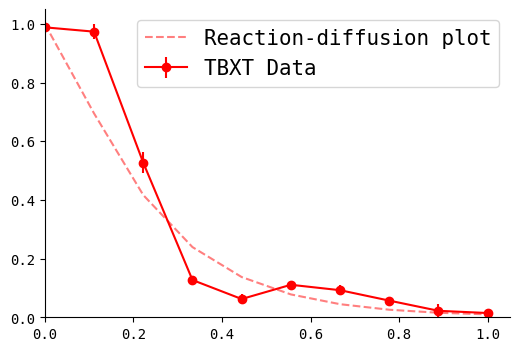

In [61]:
# plot figure
fig, ax = plt.subplots(figsize=(6,4))
# ax.plot(data_x, mean_intensity)
# ax.fill_between(data_x, 
#                 mean_intensity-std_intensity,
#                 mean_intensity+std_intensity,
#                 alpha=0.3)
ax.errorbar(data_x,
            mean_intensity_R350,
            yerr=std_intensity_R350,
            color="Red",
            fmt='o-',
            label="TBXT Data")
ax.plot(x, intensities_R800, "--", color="Red", alpha=0.5, label="Reaction-diffusion plot")

# ax.errorbar(data_x,
#             mean_intensity_R800,
#             yerr=std_intensity_R800,
#             color="Purple",
#             fmt='o-',
#             label="TBXT Data")
# x = np.linspace(0, 1, len(intensities_R800))
# ax.plot(x, intensities_R800, "--", color="Purple", alpha=0.5, label="Reaction-diffusion plot")

ax.set_xlim(0)
ax.set_ylim(0)
ax.legend(fontsize=15)